## 1. Load the datasets

ID dataset download and loading

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassan06/nslkdd")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nslkdd' dataset.
Path to dataset files: /kaggle/input/nslkdd


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
RANDOM_STATE = 42


In [3]:
nsl_test_path = path + "/KDDTest+.txt"
nsl_train_path = path + "/KDDTrain+.txt"
unsw_train_path = "/content/unsw_train.csv"
unsw_test_path = "/content/unsw_test.csv"

nsl_columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label",
    "difficulty_level"
]

nsl_train = pd.read_csv(nsl_train_path, names = nsl_columns)
nsl_test = pd.read_csv(nsl_test_path, names = nsl_columns)
unsw_train = pd.read_csv(unsw_train_path)
unsw_test = pd.read_csv(unsw_test_path)
print("NSL train:", nsl_train.shape)
print("NSL test: ", nsl_test.shape)
print("UNSW train:", unsw_train.shape)
print("UNSW test: ", unsw_test.shape)

NSL train: (125973, 43)
NSL test:  (22544, 43)
UNSW train: (82332, 45)
UNSW test:  (175341, 45)


In [4]:
nsl_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
unsw_train.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


## 2. Data-quality checks
check:
- dataset dimensions
- data types
- missing values
- duplicate rows
- constant columns

In [6]:
def basic_report(df, name):
    return pd.Series({
        "rows": len(df),
        "columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "numeric_columns": int(df.select_dtypes(include=np.number).shape[1]),
        "categorical_columns": int(df.select_dtypes(exclude=np.number).shape[1]),
    }, name=name)

quality_report = pd.concat([
    basic_report(nsl_train, "NSL train"),
    basic_report(nsl_test, "NSL test"),
    basic_report(unsw_train, "UNSW train"),
    basic_report(unsw_test, "UNSW test"),
], axis=1).T

display(quality_report)

,rows,columns,missing_cells,duplicate_rows,numeric_columns,categorical_columns
NSL train,125973,43,0,0,39,4
NSL test,22544,43,0,0,39,4
UNSW train,82332,45,0,0,41,4
UNSW test,175341,45,0,0,41,4


# Handel missing value

In [7]:
unsw_train.isna().sum().sort_values(ascending=False)
display(unsw_train[unsw_train.isna().any(axis=1)])
unsw_train = unsw_train.dropna(how="any").reset_index(drop=True)
display(unsw_train[unsw_train.isna().any(axis=1)])

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label


In [8]:
display(unsw_test[unsw_test.isna().any(axis=1)])
unsw_test = unsw_test.dropna(how="any").reset_index(drop=True)
display(unsw_test[unsw_test.isna().any(axis=1)])

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label


service is the application protocol determined by Argus and Bro. service = '-': No application service could be identified.

In [9]:
def constant_columns(df):
    return [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

print("NSL train constant columns:", constant_columns(nsl_train))
print("UNSW train constant columns:", constant_columns(unsw_train))

NSL train constant columns: ['num_outbound_cmds']
UNSW train constant columns: []


# 3. Label distributions

In [10]:
# normal = 0, attack =1
nsl_train["binary_label"] = nsl_train["label"].apply(lambda x: 0 if x == "normal" else 1)
nsl_test["binary_label"] = nsl_test["label"].apply(lambda x: 0 if x == "normal" else 1)

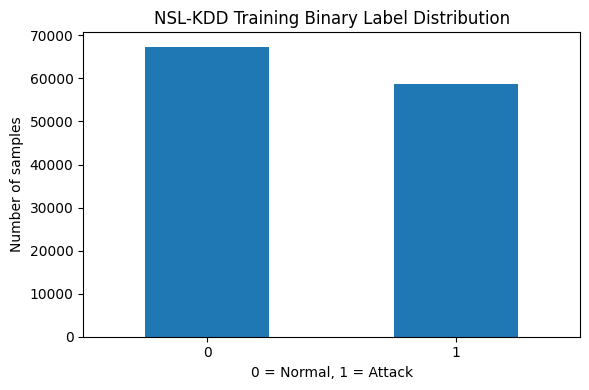

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
nsl_train["binary_label"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("NSL-KDD Training Binary Label Distribution")
ax.set_xlabel("0 = Normal, 1 = Attack")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [12]:
nsl_train["label"].value_counts()

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


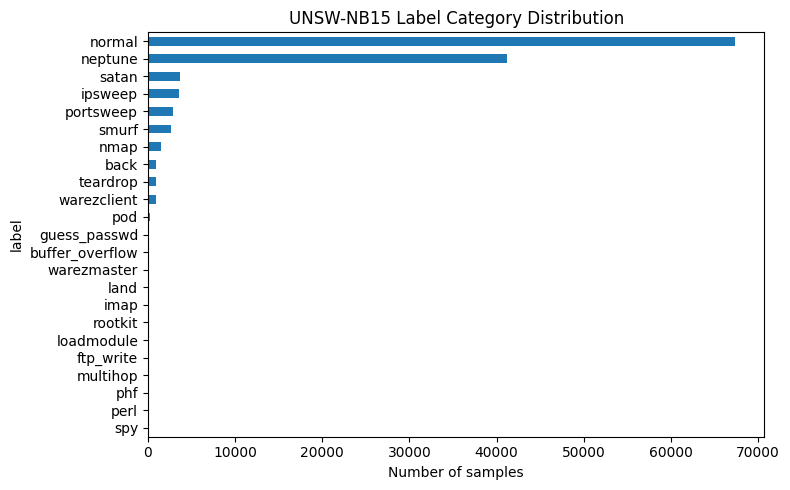

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
nsl_train["label"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("UNSW-NB15 Label Category Distribution")
ax.set_xlabel("Number of samples")
plt.tight_layout()
plt.show()

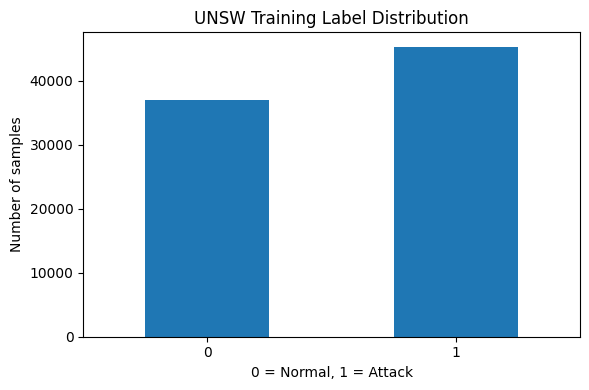

In [14]:
ig, ax = plt.subplots(figsize=(6, 4))
unsw_train["label"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("UNSW Training Label Distribution")
ax.set_xlabel("0 = Normal, 1 = Attack")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


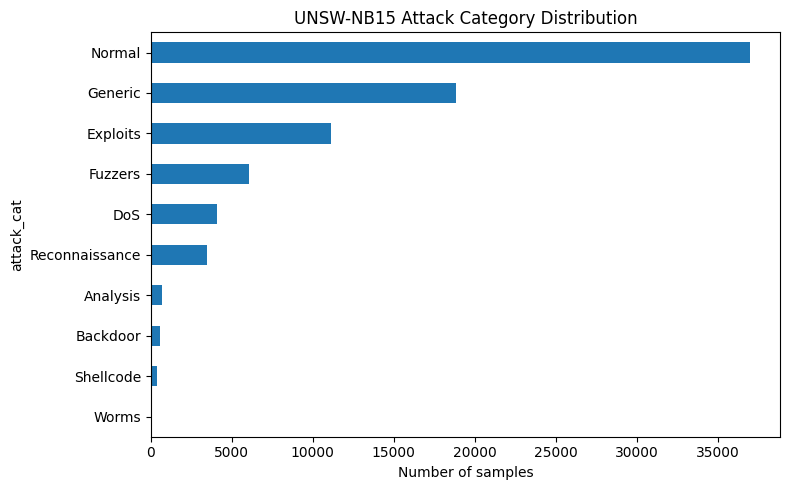

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
unsw_train["attack_cat"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("UNSW-NB15 Attack Category Distribution")
ax.set_xlabel("Number of samples")
plt.tight_layout()
plt.show()


In [16]:
nsl_train['flag'].value_counts()

,count
flag,
SF,74945
S0,34851
REJ,11233
RSTR,2421
RSTO,1562
S1,365
SH,271
S2,127
RSTOS0,103


## 4. Service distribution

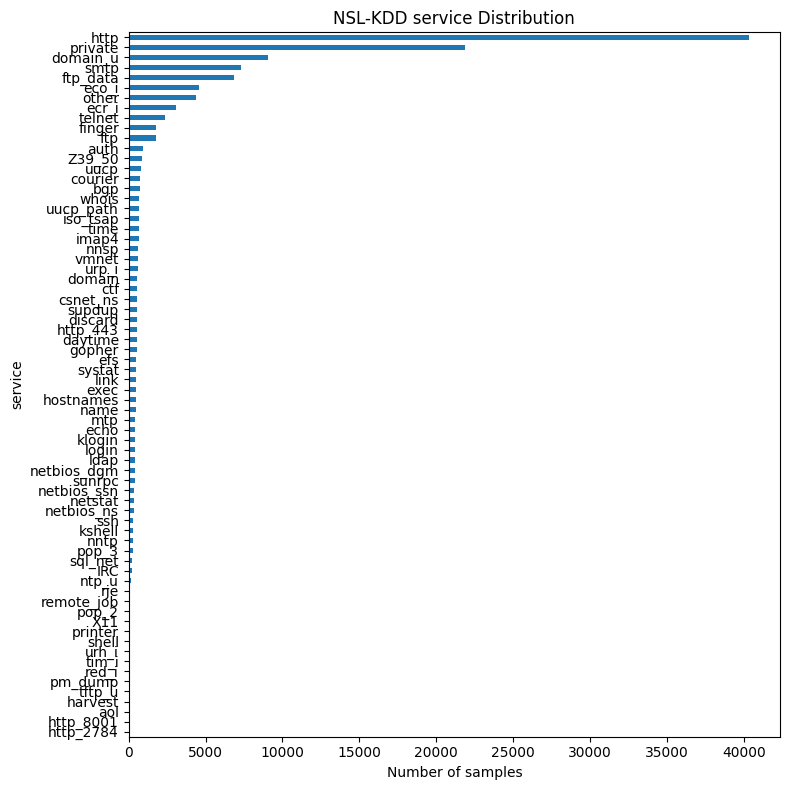

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
nsl_train["service"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("NSL-KDD service Distribution")
ax.set_xlabel("Number of samples")
plt.tight_layout()
plt.show()

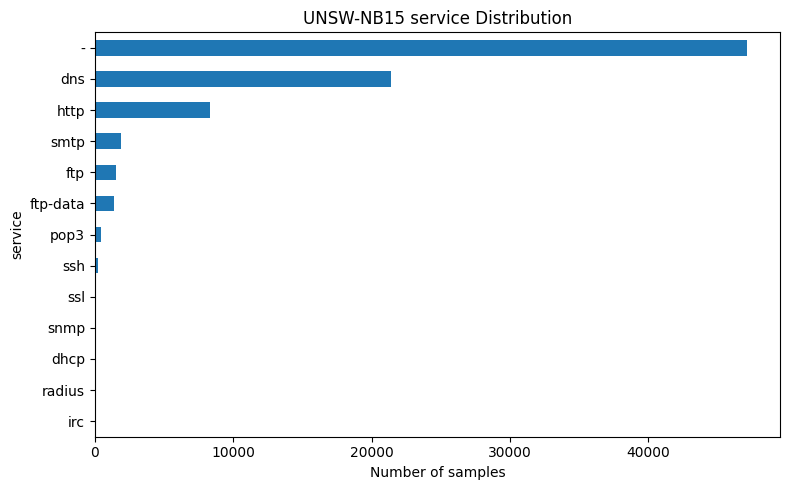

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
unsw_train["service"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("UNSW-NB15 service Distribution")
ax.set_xlabel("Number of samples")
plt.tight_layout()
plt.show()

## 5. Protocol distrubition

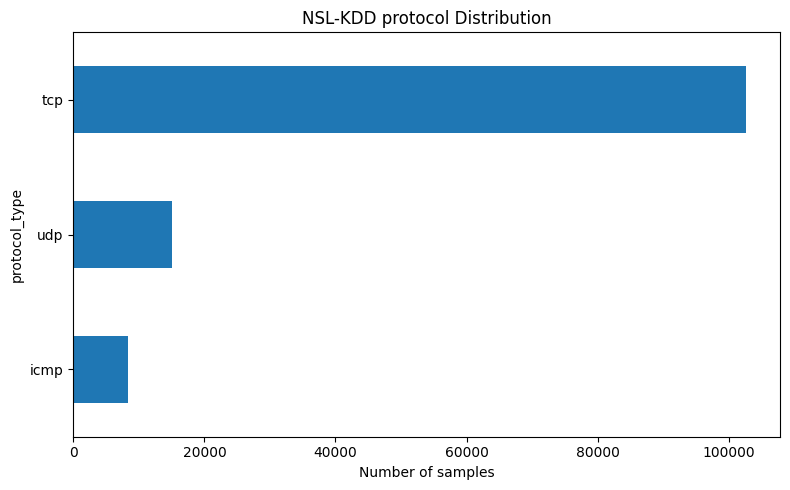

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
nsl_train["protocol_type"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("NSL-KDD protocol Distribution")
ax.set_xlabel("Number of samples")
plt.tight_layout()
plt.show()

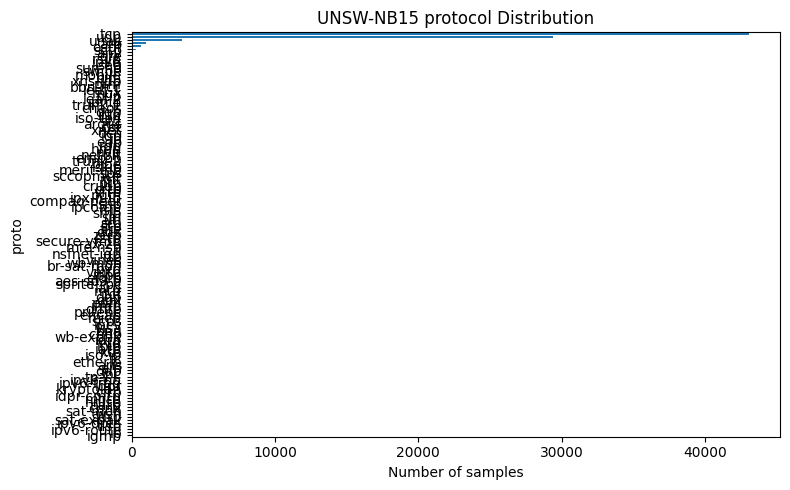

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
unsw_train["proto"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("UNSW-NB15 protocol Distribution")
ax.set_xlabel("Number of samples")
plt.tight_layout()
plt.show()

## 6. Numerical EDA for aligned features

In [21]:
nsl_train['src_bytes'].skew()

np.float64(190.66934695401906)

In [22]:
nsl_train['src_bytes'].describe(
    percentiles=[0.5,0.9,0.95,0.99]
)


,src_bytes
count,1.259730e+05
mean,4.556674e+04
std,5.870331e+06
min,0.000000e+00
50%,4.400000e+01
90%,8.480000e+02
95%,1.480000e+03
99%,5.454000e+04
max,1.379964e+09


In [23]:
nsl_numeric = nsl_train[
    ["duration", "src_bytes", "dst_bytes", "dst_host_count", "dst_host_srv_count"]
].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).T

unsw_numeric = unsw_train[
    ["dur", "sbytes", "dbytes", "ct_dst_ltm", "ct_srv_dst"]
].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).T

print("NSL candidate features")
display(nsl_numeric)

print("UNSW candidate features")
display(unsw_numeric)

NSL candidate features


,count,mean,std,min,25%,50%,75%,95%,99%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.0,9590.56,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1480.0,54540.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,8314.0,25519.00,1.309937e+09
dst_host_count,125973.0,182.148945,9.920621e+01,0.0,82.0,255.0,255.0,255.0,255.00,2.550000e+02
dst_host_srv_count,125973.0,115.653005,1.107027e+02,0.0,10.0,63.0,255.0,255.0,255.00,2.550000e+02


UNSW candidate features


,count,mean,std,min,25%,50%,75%,95%,99%,max
dur,82332.0,1.006756,4.710444,0.0,0.000008,0.014138,0.71936,2.403792,22.04829,5.999999e+01
sbytes,82332.0,7993.908165,171642.261880,24.0,114.000000,534.000000,1280.00000,12472.000000,69970.04000,1.435577e+07
dbytes,82332.0,13233.785563,151471.456091,0.0,0.000000,178.000000,956.00000,30622.000000,207751.00000,1.465753e+07
ct_dst_ltm,82332.0,5.744923,8.418112,1.0,1.000000,2.000000,6.00000,25.000000,43.00000,5.900000e+01
ct_srv_dst,82332.0,9.164262,11.121413,1.0,2.000000,5.000000,11.00000,36.000000,46.00000,6.200000e+01


## Outlier NSL-KDD:
Boxplots identified numerous statistical outliers in src_bytes. Further inspection showed that these observations correspond to both attack traffic (e.g., portsweep) and legitimate traffic (e.g., X11) rather than obvious data-entry errors. Therefore, these extreme values were retained during preprocessing. Instead of removing them, log-transformed visualizations were used to better illustrate their distributions.

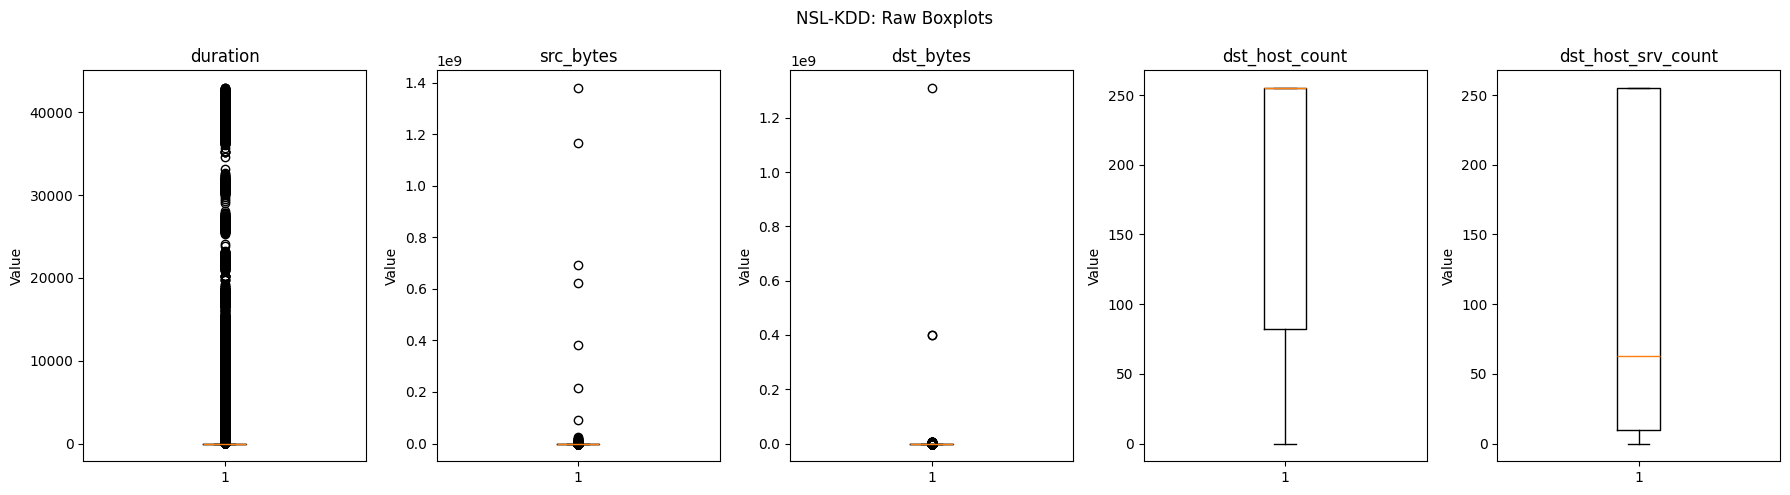

In [24]:
features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "dst_host_count",
    "dst_host_srv_count"
]

fig, axes = plt.subplots(1, len(features), figsize=(18, 5))

for ax, feature in zip(axes, features):
    ax.boxplot(nsl_train[feature], vert=True)
    ax.set_title(feature)
    ax.set_ylabel("Value")

plt.suptitle("NSL-KDD: Raw Boxplots")
plt.tight_layout()
plt.show()

In [25]:
nsl_train.nlargest(
    10,
    "src_bytes"
)[
    [
        "src_bytes",
        "duration",
        "protocol_type",
        "service",
        "label",
        "binary_label"
    ]
]

,src_bytes,duration,protocol_type,service,label,binary_label
125429,1379963888,36071,tcp,ftp,portsweep,1
44527,1167519497,34578,tcp,private,portsweep,1
60570,693375640,2,tcp,finger,portsweep,1
43486,621568663,38259,tcp,discard,portsweep,1
1038,381709090,35682,tcp,telnet,portsweep,1
91546,217277339,35301,tcp,smtp,portsweep,1
111229,89581520,5158,tcp,X11,normal,0
49323,24418776,103,tcp,X11,normal,0
108124,21945520,388,tcp,X11,normal,0
45575,18828976,31,tcp,X11,normal,0


In [26]:
nsl_train.nlargest(
    10,
    "duration"
)[
    [
        "duration",
        "src_bytes",
        "protocol_type",
        "service",
        "label",
        "binary_label"
    ]
]

,duration,src_bytes,protocol_type,service,label,binary_label
58651,42908,1,tcp,private,portsweep,1
105875,42888,1,tcp,private,portsweep,1
25061,42862,1,tcp,private,portsweep,1
66806,42837,1,tcp,private,portsweep,1
124539,42804,1,tcp,private,portsweep,1
116222,42778,1,tcp,private,portsweep,1
100678,42746,1,tcp,echo,portsweep,1
87109,42723,1,tcp,private,portsweep,1
33677,42699,1,tcp,discard,portsweep,1
31043,42679,1,tcp,private,portsweep,1


In [27]:
nsl_train.nlargest(
    10,
    "dst_bytes"
)[
    [
        "dst_bytes",
        "duration",
        "protocol_type",
        "service",
        "label",
        "binary_label"
    ]
]

,dst_bytes,duration,protocol_type,service,label,binary_label
62233,1309937401,10999,tcp,other,portsweep,1
71629,400291060,39930,tcp,private,portsweep,1
95029,400291060,39869,tcp,private,portsweep,1
111229,7028652,5158,tcp,X11,normal,0
110158,5155468,10,tcp,ftp_data,warezmaster,1
33767,5153771,9,tcp,ftp_data,warezmaster,1
114997,5153460,9,tcp,ftp_data,warezmaster,1
24417,5151385,10,tcp,ftp_data,warezmaster,1
59961,5151154,10,tcp,ftp_data,warezmaster,1
31647,5151049,9,tcp,ftp_data,warezmaster,1


We applied log1p for visualization because src_bytes, dst_bytes, and duration are highly right-skewed. The log transformation makes the distributions easier to compare between NSL-KDD and UNSW-NB15.

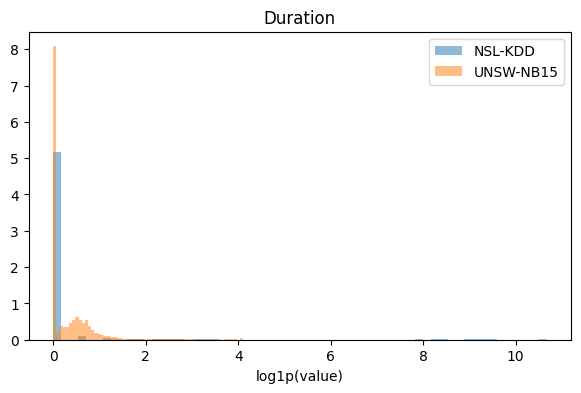

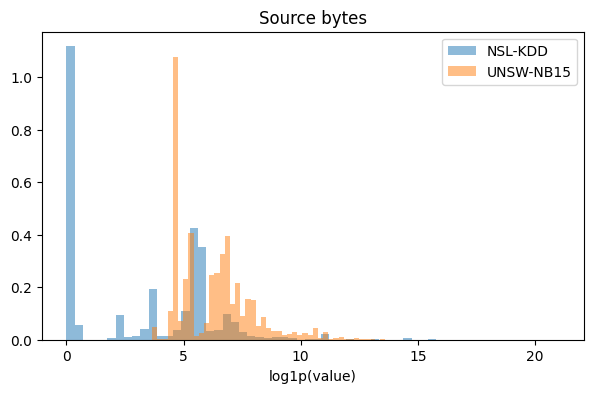

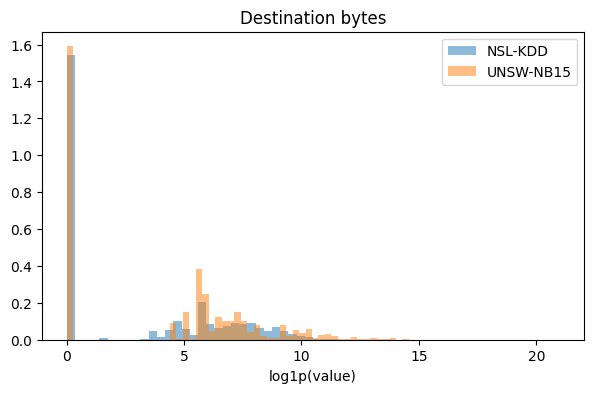

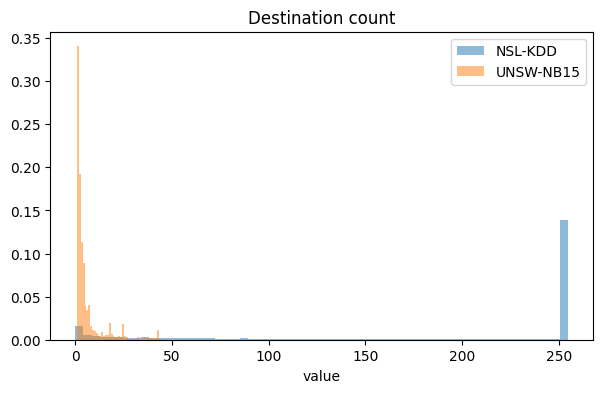

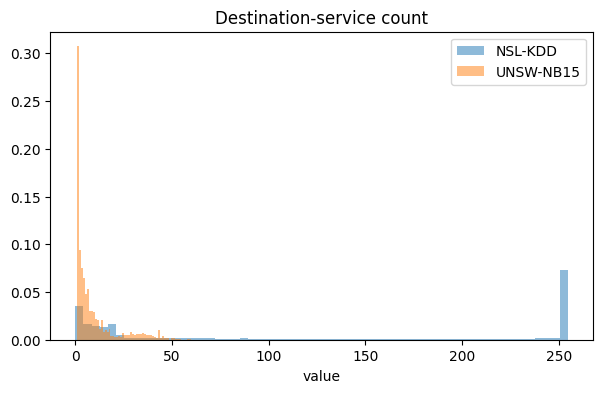

In [28]:
pairs = [ ("duration", "dur", "Duration"),
          ("src_bytes", "sbytes", "Source bytes"),
          ("dst_bytes", "dbytes", "Destination bytes"),
          ("dst_host_count", "ct_dst_ltm", "Destination count"),
          ("dst_host_srv_count", "ct_srv_dst", "Destination-service count"),
        ]

log_features = {
    "duration",
    "src_bytes",
    "dst_bytes"
}

for nsl_col, unsw_col, title in pairs:

    nsl_data = nsl_train[nsl_col].clip(lower=0)
    unsw_data = unsw_train[unsw_col].clip(lower=0)

    if nsl_col in log_features:
        nsl_data = np.log1p(nsl_data)
        unsw_data = np.log1p(unsw_data)
        xlabel = "log1p(value)"
    else:
        xlabel = "value"

    fig, ax = plt.subplots(figsize=(7,4))

    ax.hist(nsl_data, bins=60, density=True,
            alpha=0.5, label="NSL-KDD")
    ax.hist(unsw_data, bins=60, density=True,
            alpha=0.5, label="UNSW-NB15")

    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend()
    plt.show()

## 7. Inspect the candidate shared features

### Strict alignment

| Canonical feature | NSL-KDD | UNSW-NB15 | Reason|
|---|---|---|---|
| duration | `duration` | `dur` | identical definition|
| protocol | `protocol_type` | `proto` | same protocol semantics|
| service | `service` | `service` | same application service|
| source bytes | `src_bytes` | `sbytes` | same byte count|
| destination bytes | `dst_bytes` | `dbytes` | same byte count|
| label | `label` | `label` |


### Approximate extension

| Canonical feature | NSL-KDD | UNSW-NB15 | Reason|
|---|---|---|---|
| flag | `flag` | `state` | Similar semantics, different encoding|
| destination count | `dst_host_count` | `ct_dst_ltm` | approximate destination count|
| destination-service count | `dst_host_srv_count` | `ct_srv_dst` | approximate destination-service count|

The final two pairs are **semantically related but not mathematically identical** because the datasets use different traffic-window definitions.


In [29]:
nsl_protocols = set(nsl_train["protocol_type"].astype(str).str.lower())
unsw_protocols = set(unsw_train["proto"].astype(str).str.lower())

nsl_services = set(nsl_train["service"].astype(str).str.lower())
unsw_services = set(unsw_train["service"].astype(str).str.lower())

print("NSL protocols:", sorted(nsl_protocols))
print("UNSW protocols:", sorted(unsw_protocols))
print("Protocol overlap:", sorted(nsl_protocols & unsw_protocols))

print("\nNumber of NSL services:", len(nsl_services))
print("Number of UNSW services:", len(unsw_services))
print("Service overlap:", sorted(nsl_services & unsw_services))


NSL protocols: ['icmp', 'tcp', 'udp']
UNSW protocols: ['3pc', 'a/n', 'aes-sp3-d', 'any', 'argus', 'aris', 'arp', 'ax.25', 'bbn-rcc', 'bna', 'br-sat-mon', 'cbt', 'cftp', 'chaos', 'compaq-peer', 'cphb', 'cpnx', 'crtp', 'crudp', 'dcn', 'ddp', 'ddx', 'dgp', 'egp', 'eigrp', 'emcon', 'encap', 'etherip', 'fc', 'fire', 'ggp', 'gmtp', 'gre', 'hmp', 'i-nlsp', 'iatp', 'ib', 'idpr', 'idpr-cmtp', 'idrp', 'ifmp', 'igmp', 'igp', 'il', 'ip', 'ipcomp', 'ipcv', 'ipip', 'iplt', 'ipnip', 'ippc', 'ipv6', 'ipv6-frag', 'ipv6-no', 'ipv6-opts', 'ipv6-route', 'ipx-n-ip', 'irtp', 'isis', 'iso-ip', 'iso-tp4', 'kryptolan', 'l2tp', 'larp', 'leaf-1', 'leaf-2', 'merit-inp', 'mfe-nsp', 'mhrp', 'micp', 'mobile', 'mtp', 'mux', 'narp', 'netblt', 'nsfnet-igp', 'nvp', 'ospf', 'pgm', 'pim', 'pipe', 'pnni', 'pri-enc', 'prm', 'ptp', 'pup', 'pvp', 'qnx', 'rdp', 'rsvp', 'rvd', 'sat-expak', 'sat-mon', 'sccopmce', 'scps', 'sctp', 'sdrp', 'secure-vmtp', 'sep', 'skip', 'sm', 'smp', 'snp', 'sprite-rpc', 'sps', 'srp', 'st2', 'stp', '

## 8. Align the feature schemas and split ID dataset to 3 parts


In [30]:
mapping = {
    "duration": "dur",
    "protocol_type": "proto",
    "service": "service",
    "src_bytes": "sbytes",
    "dst_bytes": "dbytes",
    "dst_host_count": "ct_dst_ltm",
    "dst_host_srv_count": "ct_srv_dst",
}

In [31]:
FEATURE_MODE = "extended"

def clean_category(series):
    return (
        series.astype("string")
        .fillna("unknown")
        .str.strip()
        .str.lower()
        .replace({"": "unknown", "-": "unknown"})
    )

def align_nsl(df, mode="extended"):
    aligned = pd.DataFrame(index=df.index)
    aligned["duration"] = pd.to_numeric(df["duration"], errors="coerce")
    aligned["src_bytes"] = pd.to_numeric(df["src_bytes"], errors="coerce")
    aligned["dst_bytes"] = pd.to_numeric(df["dst_bytes"], errors="coerce")
    aligned["protocol"] = clean_category(df["protocol_type"])
    aligned["service"] = clean_category(df["service"])

    if mode == "extended":
        aligned["destination_count"] = pd.to_numeric(
            df["dst_host_count"], errors="coerce"
        )
        aligned["destination_service_count"] = pd.to_numeric(
            df["dst_host_srv_count"], errors="coerce"
        )

    return aligned

def align_unsw(df, mode="extended"):
    aligned = pd.DataFrame(index=df.index)
    aligned["duration"] = pd.to_numeric(df["dur"], errors="coerce")
    aligned["src_bytes"] = pd.to_numeric(df["sbytes"], errors="coerce")
    aligned["dst_bytes"] = pd.to_numeric(df["dbytes"], errors="coerce")
    aligned["protocol"] = clean_category(df["proto"])
    aligned["service"] = clean_category(df["service"])

    if mode == "extended":
        aligned["destination_count"] = pd.to_numeric(
            df["ct_dst_ltm"], errors="coerce"
        )
        aligned["destination_service_count"] = pd.to_numeric(
            df["ct_srv_dst"], errors="coerce"
        )

    return aligned

In [32]:
# split nsl_train to train and validation
from sklearn.model_selection import train_test_split

nsl_train_split, nsl_val = train_test_split(
    nsl_train,
    test_size=0.2,
    random_state=42,
    stratify=nsl_train["binary_label"],
)

# feature alignment
X_train_df = align_nsl(nsl_train_split, FEATURE_MODE)
X_val_df = align_nsl(nsl_val, FEATURE_MODE)
X_test_df = align_nsl(nsl_test, FEATURE_MODE)

X_ood_train_df = align_unsw(unsw_train, FEATURE_MODE)
X_ood_test_df = align_unsw(unsw_test, FEATURE_MODE)

y_train = nsl_train_split["binary_label"].to_numpy()

y_val = nsl_val["binary_label"].to_numpy()

y_test = nsl_test["binary_label"].to_numpy()

# OOD labels (for evaluation / Layer 2 later)
y_ood_train = unsw_train["label"].astype(int).to_numpy()
y_ood_test = unsw_test["label"].astype(int).to_numpy()

display(X_train_df.head())
display(X_ood_train_df.head())

,duration,src_bytes,dst_bytes,protocol,service,destination_count,destination_service_count
23630,0,330,717,tcp,http,245,255
39958,1,1300,368,tcp,smtp,10,82
15456,10,194,954639,tcp,http,255,255
169,0,295,465,tcp,http,69,255
14833,0,315,462,tcp,http,255,255


,duration,src_bytes,dst_bytes,protocol,service,destination_count,destination_service_count
0,0.000011,496,0,udp,unknown,1,2
1,0.000008,1762,0,udp,unknown,1,2
2,0.000005,1068,0,udp,unknown,1,3
3,0.000006,900,0,udp,unknown,2,3
4,0.000010,2126,0,udp,unknown,2,3


In [33]:
print("NSL train:", X_train_df.isna().sum().sum())
print("NSL test: ", X_test_df.isna().sum().sum())
print("UNSW train:", X_ood_train_df.isna().sum().sum())
print("UNSW test: ", X_ood_test_df.isna().sum().sum())

NSL train: 0
NSL test:  0
UNSW train: 0
UNSW test:  0


## 9. Encoding and scaling
We fit the entire preprocessing pipeline only on the NSL-KDD training set. For numerical features, StandardScaler learns the mean and standard deviation from the ID training data and applies the same transformation to the validation, test, and OOD datasets.

For categorical features, OneHotEncoder learns the category mapping from the ID training set only. When transforming the UNSW-NB15 data, any unseen category (e.g., a protocol or service not observed during training) is handled by handle_unknown="ignore". Instead of creating a new feature column, the encoder assigns zeros to all one-hot columns corresponding to that categorical feature. This ensures that the ID and OOD datasets always have exactly the same input feature dimensions.

In [34]:
numeric_columns = ["duration", "src_bytes", "dst_bytes"]

if FEATURE_MODE == "extended":
    numeric_columns += ["destination_count", "destination_service_count"]

categorical_columns = ["protocol", "service"]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("scaler", StandardScaler())
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32,
            ),
            categorical_columns,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Fit only on ID training data.
X_train = preprocessor.fit_transform(X_train_df)

# Reuse exactly the same fitted transformer.
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)
X_ood_train = preprocessor.transform(X_ood_train_df)
X_ood_test = preprocessor.transform(X_ood_test_df)

X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)
X_ood_train = np.asarray(X_ood_train, dtype=np.float32)
X_ood_test = np.asarray(X_ood_test, dtype=np.float32)

feature_names = preprocessor.get_feature_names_out()

print("Mode:", FEATURE_MODE)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("X_ood_train:", X_ood_train.shape)
print("X_ood_test:", X_ood_test.shape)
print("Output feature count:", len(feature_names))
print("First output features:", feature_names[:20])

Mode: extended
X_train: (100778, 77)
X_val: (25195, 77)
X_test: (22544, 77)
X_ood_train: (82332, 77)
X_ood_test: (175341, 77)
Output feature count: 77
First output features: ['duration' 'src_bytes' 'dst_bytes' 'destination_count'
 'destination_service_count' 'protocol_icmp' 'protocol_tcp' 'protocol_udp'
 'service_aol' 'service_auth' 'service_bgp' 'service_courier'
 'service_csnet_ns' 'service_ctf' 'service_daytime' 'service_discard'
 'service_domain' 'service_domain_u' 'service_echo' 'service_eco_i']


In [35]:
X_train[0]

array([-0.11076393, -0.00737941, -0.00512427,  0.6335273 ,  1.2591056 ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  